[Crowell et al.](https://www.biorxiv.org/content/10.1101/2025.06.23.660674v1) data, available via [Zenodo](http://10.0.20.161/zenodo.15574384)

In [2]:
import dask
dask.config.set({"dataframe.query-planning": True})

In [3]:
import dask.dataframe as dd

In [4]:
import scanpy as sc
import gc
import scipy.sparse as sp

from tqdm.autonotebook import tqdm
from scipy.sparse import csr_matrix
from anndata.experimental import concat_on_disk

from cellina._spatial_utils import spatial_neighbors

/tmp/ipykernel_1705789/3225973611.py:5: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import tqdm


In [5]:
import sys

sys.path.append("../../scripts")

In [6]:
base_path = "/data2/a330d/datasets/crc"
#base_path = "/data/a330d/datasets/crc"
joint_adata_path = f'{base_path}/processed/crc_cosmx_wt.h5ad'

## Create merged adata

In [6]:
data_list = ['110', '120', '210', '221', '231', '232', '242']

In [8]:
# Create tmp files with csr matrices (since the original files have csc, which causes issues with concatenation)
tmp_files = []

for idx in tqdm(data_list, desc="Converting to CSR"):
    ad = sc.read(f"{base_path}/raw_zenodo/crc_{idx}.h5ad",
                 backup_url=f"https://zenodo.org/records/15574384/files/{idx}.h5ad?download=1")

    if sp.isspmatrix_csc(ad.X):
        ad.X = ad.X.tocsr()

    tmp = f"/data/a330d/tmp/{idx}_csr.h5ad"
    ad.write(tmp)
    tmp_files.append(tmp)

100%|██████████| 2.13G/2.13G [03:35<00:00, 10.6MB/s], 20.92s/it]
100%|██████████| 1.05G/1.05G [01:38<00:00, 11.5MB/s], 156.02s/it]
100%|██████████| 669M/669M [03:56<00:00, 2.97MB/s]05, 136.47s/it]
100%|██████████| 510M/510M [01:55<00:00, 4.62MB/s]59, 179.67s/it]
100%|██████████| 216M/216M [00:42<00:00, 5.33MB/s]18, 159.24s/it]
100%|██████████| 1.03G/1.03G [01:45<00:00, 10.4MB/s], 120.66s/it]
Converting to CSR: 100%|██████████| 7/7 [15:20<00:00, 131.44s/it]


In [11]:
# Sequentially merge the rest (avoid exploding RAM)
for idx in tqdm(data_list, desc="Merging slides"):
    concat_on_disk(
    [f"/data/a330d/tmp/{idx}_csr.h5ad" for idx in data_list],
    out_file=joint_adata_path,
    join="inner"
)

Merging slides: 100%|██████████| 7/7 [08:32<00:00, 73.17s/it]


## Read Object

In [6]:
adata = sc.read_h5ad(joint_adata_path)

/data/a330d/miniforge3/envs/cellina-base/lib/python3.11/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


run - batch identifier (1 or 2)

sec - per-slide section identifier (1 or 2)

rep - pre-run donor identifier (1-2 for 1st, 1-4 for 2nd run)

did - slide identifier (run+rep, e.g., 12 for 1st run, 2nd slide)

sid - section identifier (run+rep+sec; xx0 for single-section slides)

pid - clinical sample identifier (unique except for sections 231/232)

fov - field of view (FOV) correspondence (n/a = all FOVs)

In [7]:
# Change back to csc - helps with downstream stuff
adata.X = adata.X.tocsc()

In [8]:
adata.obs[[
    'rep', # 2 replicates per donor?
    'sid', # sample id
    "did", # NOTE: donor id
    # To identify concordant microenvironments across sections and domains, 
    # we further clustered cells based on the subpopulation composition of their local neighborhood to obtain 10 spatial niches
    'ctx', 
 ]].drop_duplicates()

,rep,sid,did,ctx
c_1_1_1,1,110,11,N3
c_1_1_3,1,110,11,NaN
c_1_1_19,1,110,11,N6
c_1_1_134,1,110,11,N8
c_1_1_135,1,110,11,N1
...,...,...,...,...
c_4_35_443,4,242,24,N8
c_4_35_557,4,242,24,N6
c_4_36_10,4,242,24,N3
c_4_41_98,4,242,24,N1


In [9]:
adata.obsm['spatial'] = adata.obs[['CenterX_global_px', 'CenterY_global_px']].values

In [10]:
slide_key = 'sid'

sc.pp.filter_genes(adata, min_cells=100)

/data/a330d/miniforge3/envs/cellina-base/lib/python3.11/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [11]:
adata = adata[~adata.obs['ist'].isna()]
adata.obs['ist'] = adata.obs['ist'].astype(str)

/tmp/ipykernel_2683084/3451605068.py:2: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs['ist'] = adata.obs['ist'].astype(str)
/data/a330d/miniforge3/envs/cellina-base/lib/python3.11/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [12]:
adata.layers['counts'] = adata.X.copy()

In [13]:
adata.write_h5ad(joint_adata_path)

## 2. Data Preprocessing

In [7]:
adata = sc.read_h5ad(joint_adata_path)

/data/a330d/miniforge3/envs/cellina-base/lib/python3.11/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [8]:
# Compute spatial connectivity matrix
#from benchmark_pipeline import K_NN
K_NN = 200
label_col = "ist"
slide_key = "sid"

In [9]:
from _labels_to_coarse import LABEL_TO_COARSE

adata.obs["coarse_type"] = adata.obs[label_col].map(LABEL_TO_COARSE)
label_col = "coarse_type"

In [10]:
sc.pp.highly_variable_genes(adata, layer='counts', flavor='seurat_v3', n_top_genes=2000, subset=True)

/data/a330d/miniforge3/envs/cellina-base/lib/python3.11/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


## Ligands

In [11]:
import pandas as pd
import numpy as np

import requests
import io

# read csv from link
# https://github.com/ventolab/cellphonedb-data/blob/master/data/interaction_input.csv
resource = requests.get('https://raw.githubusercontent.com/ventolab/cellphonedb-data/master/data/interaction_input.csv').content
resource = io.StringIO(resource.decode('utf-8'))
resource = pd.read_csv(resource, sep=',')
# keep only PPIs
resource = resource[resource['is_ppi']][['interactors']]
# replace + with _
resource['interactors'] = resource['interactors'].apply(lambda x: x.replace('+', '_'))
# if interactors contains two '-' replace the first one with '&
resource['interactors'] = resource['interactors'].apply(lambda x: x.replace('-', '&', 1) if x.count('-') == 2 else x)
# split by - and expand
resource = resource['interactors'].str.split('-', expand=True)
# replace & with - in the first column
resource[0] = resource[0].apply(lambda x: x.replace('&', '-'))
resource.columns = ['ligand', 'receptor']


In [12]:
# Split ligands on '_' to get list of subunits
resource['ligand'] = resource['ligand'].str.split('_')
# Explode the list into separate rows
resource = resource.explode('ligand').reset_index(drop=True)
ligands = resource['ligand'].unique()

In [13]:
# Split receptors on '_' to get list of subunits
resource['receptor'] = resource['receptor'].str.split('_')
# Explode the list into separate rows
resource = resource.explode('receptor').reset_index(drop=True)
receptors = resource['receptor'].unique()

In [14]:
ligands_in_data = [g for g in ligands if g in adata.var_names]
receptors_in_data = [g for g in receptors if g in adata.var_names]

In [15]:
len(ligands_in_data), len(receptors_in_data)

(161, 79)

In [16]:
use_ligands = False
use_receptors = False

neighbor_features = adata.var_names
if use_ligands:
    neighbor_features = ligands_in_data
if use_receptors:
    neighbor_features = neighbor_features + receptors_in_data

In [ ]:
# 1. Find which cell types are present in ALL slides
# Count how many unique slides there are
all_slides = adata.obs[slide_key].unique()
num_slides = len(all_slides)

# 2. Count slides per cell type
slides_per_celltype = adata.obs.groupby(label_col)[slide_key].nunique()

# 3. Select cell types that appear in all slides
celltypes_in_all_slides = slides_per_celltype[slides_per_celltype == num_slides].index.tolist()

# 4. Filter obs to keep only these cell types
adata = adata[adata.obs[label_col].isin(celltypes_in_all_slides)]

In [17]:
from cellina._spatial_utils import compute_spatial_features

In [18]:
slides = adata.obs[slide_key].unique()
adata_out = None  # initialize output AnnData

for sid in tqdm(slides, desc="Adding spatial_x to slides"):
    ad_slide = adata[adata.obs[slide_key] == sid].copy()

    #spatial_neighbors(ad_slide, bandwidth=np.inf, max_neighbours=K_NN, standardize=False)
    spatial_neighbors(ad_slide, bandwidth=100 / 0.12028, max_neighbours=K_NN, standardize=False)
    ad_slide.obs['neighbor'] = ad_slide.obsp['spatial_connectivities'][:,0].toarray().astype(np.float32)

    sc.pp.normalize_total(ad_slide, target_sum=1e4)
    sc.pp.log1p(ad_slide)
    #ad_slide.obsm['spatial_x'] = ad_slide.obsp['spatial_connectivities'] @ ad_slide[:, neighbor_features].X / K_NN
    #ad_slide.obsm['spatial_x'] = csr_matrix(ad_slide.obsm['spatial_x']).astype(np.float32)
    compute_spatial_features(ad_slide)

    # Incremental concatenation
    if adata_out is None:
        adata_out = ad_slide
    else:
        adata_out = sc.concat([adata_out, ad_slide])

adata = adata_out

Adding spatial_x to slides:  29%|██▊       | 2/7 [04:00<10:14, 122.80s/it]/data/a330d/miniforge3/envs/cellina-base/lib/python3.11/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
Adding spatial_x to slides:  43%|████▎     | 3/7 [05:39<07:28, 112.12s/it]/data/a330d/miniforge3/envs/cellina-base/lib/python3.11/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
Adding spatial_x to slides:  57%|█████▋    | 4/7 [06:50<04:47, 95.91s/it] /data/a330d/miniforge3/envs/cellina-base/lib/python3.11/site-packages/legacy_api_wrap/__init__.py:88: UserWarning: Some cells have zero counts
  return fn(*args_all, **kw)
/data/a330d/miniforge3/envs/cellina-base/lib/python3.11/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names 

In [19]:
adata.X.max()

np.float64(9.210440366976517)

In [20]:
adata.obsm['spatial_x'].max()

np.float32(8.186466)

In [21]:
#adata.layers['counts'] = adata.X.copy()
adata.X = adata.layers['counts'].copy()
adata.uns = ad_slide.uns.copy()

In [22]:
adata.obs["typ_clean"] = (
        adata.obs["typ"]
        .str.extract(r"(REF|TVA|CRC)", expand=False)
        )

In [23]:
adata.obs["typ_clean"] = adata.obs["typ_clean"].astype(str)
adata.obs["typ"] = adata.obs["typ"].astype(str)

In [24]:
test_samples = [110] #[221, 242]
sample_key = batch_key = "sid" # NOTE: on this or by patient, not sure
celltype_key = 'coarse_type' # NOTE: I created this
niche_key = condition_key = 'typ_clean' # NOTE: ctx - this is some cluster on cell types TBD
n_holdout = 1 #2
train_frac = 0.8

In [25]:
adata.uns['default_params'] = {
    # Data Specific Parameters
    "dataset_name": "cosmx_crc_wt",
    "K_NN": K_NN,
    "celltype_key": celltype_key,
    "niche_key": niche_key,
    "sample_key": sample_key,
    "batch_key": batch_key,
    # Split Parameters
    "n_holdout": n_holdout,
    "n_val_samples": False,
    "test_samples": test_samples,
    "train_frac": train_frac
}

In [26]:
adata.uns['default_params']

{'dataset_name': 'cosmx_crc_wt',
 'K_NN': 200,
 'celltype_key': 'coarse_type',
 'niche_key': 'typ_clean',
 'sample_key': 'sid',
 'batch_key': 'sid',
 'n_holdout': 1,
 'n_val_samples': False,
 'test_samples': [110],
 'train_frac': 0.8}

In [27]:
adata

AnnData object with n_obs × n_vars = 3101725 × 2000
    obs: 'fov', 'Area', 'AspectRatio', 'CenterX_local_px', 'CenterY_local_px', 'Width', 'Height', 'Mean.PanCK', 'Max.PanCK', 'Mean.CD68_CK8_18', 'Max.CD68_CK8_18', 'Mean.CD298_B2M', 'Max.CD298_B2M', 'Mean.CD45', 'Max.CD45', 'Mean.DAPI', 'Max.DAPI', 'cell_id', 'version', 'dualfiles', 'Run_name', 'Run_Tissue_name', 'ISH.concentration', 'Dash', 'tissue', 'Panel', 'assay_type', 'slide_ID', 'CenterX_global_px', 'CenterY_global_px', 'cell_ID', 'unassignedTranscripts', 'median_RNA', 'RNA_quantile_0.75', 'RNA_quantile_0.8', 'RNA_quantile_0.85', 'RNA_quantile_0.9', 'RNA_quantile_0.95', 'RNA_quantile_0.99', 'nCount_RNA', 'nFeature_RNA', 'median_negprobes', 'negprobes_quantile_0.75', 'negprobes_quantile_0.8', 'negprobes_quantile_0.85', 'negprobes_quantile_0.9', 'negprobes_quantile_0.95', 'negprobes_quantile_0.99', 'nCount_negprobes', 'nFeature_negprobes', 'median_falsecode', 'falsecode_quantile_0.75', 'falsecode_quantile_0.8', 'falsecode_quantil

In [28]:
adata.write_h5ad(joint_adata_path)

In [6]:
adata = sc.read_h5ad(joint_adata_path)

/data/a330d/miniforge3/envs/cellina-base/lib/python3.11/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [7]:
adata.obs_names_make_unique()

In [8]:
sc.pp.filter_cells(adata, min_counts=10)

In [9]:
# Filter out cells that have nans in obs.typ_clean
adata = adata[adata.obs["typ_clean"]!='nan']

In [10]:
adata.write_h5ad(joint_adata_path)

In [11]:
adata

View of AnnData object with n_obs × n_vars = 2971499 × 2000
    obs: 'fov', 'Area', 'AspectRatio', 'CenterX_local_px', 'CenterY_local_px', 'Width', 'Height', 'Mean.PanCK', 'Max.PanCK', 'Mean.CD68_CK8_18', 'Max.CD68_CK8_18', 'Mean.CD298_B2M', 'Max.CD298_B2M', 'Mean.CD45', 'Max.CD45', 'Mean.DAPI', 'Max.DAPI', 'cell_id', 'version', 'dualfiles', 'Run_name', 'Run_Tissue_name', 'ISH.concentration', 'Dash', 'tissue', 'Panel', 'assay_type', 'slide_ID', 'CenterX_global_px', 'CenterY_global_px', 'cell_ID', 'unassignedTranscripts', 'median_RNA', 'RNA_quantile_0.75', 'RNA_quantile_0.8', 'RNA_quantile_0.85', 'RNA_quantile_0.9', 'RNA_quantile_0.95', 'RNA_quantile_0.99', 'nCount_RNA', 'nFeature_RNA', 'median_negprobes', 'negprobes_quantile_0.75', 'negprobes_quantile_0.8', 'negprobes_quantile_0.85', 'negprobes_quantile_0.9', 'negprobes_quantile_0.95', 'negprobes_quantile_0.99', 'nCount_negprobes', 'nFeature_negprobes', 'median_falsecode', 'falsecode_quantile_0.75', 'falsecode_quantile_0.8', 'falsecode

# SIMVI small adata

In [7]:
adata = sc.read_h5ad(joint_adata_path)

In [8]:
adata.obs.sid.value_counts()

sid
120    706958
110    611021
210    549082
242    420449
221    327241
231    245222
232    111526
Name: count, dtype: int64

In [23]:
keep = [231, 242]
adata_slide = adata[adata.obs.sid.isin(keep)].copy()

/tmp/ipykernel_1705789/3126905123.py:1: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata_slide[adata_slide.obs['sid'] == 231], color='typ_clean', spot_size=100)
/data/a330d/miniforge3/envs/cellina-graph/lib/python3.10/site-packages/scanpy/plotting/_utils.py:465: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[f"{value_to_plot}_colors"] = colors_list


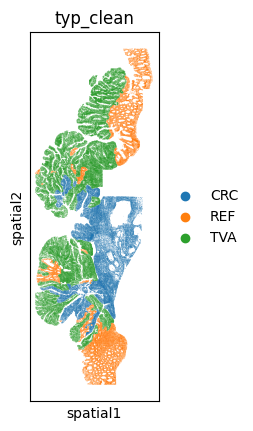

In [32]:
sc.pl.spatial(adata_slide[adata_slide.obs['sid'] == 231], color='typ_clean', spot_size=100)

/tmp/ipykernel_1705789/492856036.py:1: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata_slide[adata_slide.obs['sid'] == 242], color='typ_clean', spot_size=100)
/data/a330d/miniforge3/envs/cellina-graph/lib/python3.10/site-packages/scanpy/plotting/_utils.py:465: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[f"{value_to_plot}_colors"] = colors_list


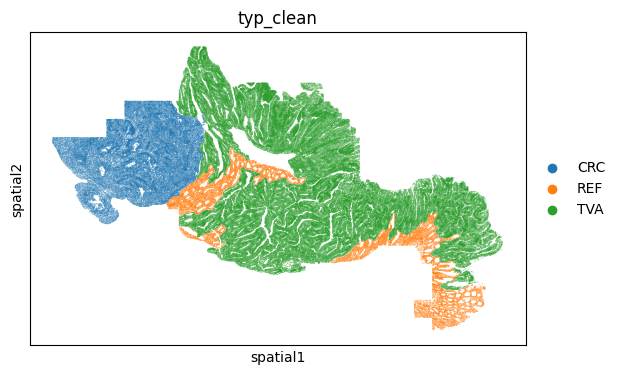

In [33]:
sc.pl.spatial(adata_slide[adata_slide.obs['sid'] == 242], color='typ_clean', spot_size=100)

In [34]:
from sklearn.neighbors import NearestNeighbors
import numpy as np


def subset_adata(adata):
    adatas = []
    for sid in adata.obs['sid'].unique():
        adata_slide = adata[adata.obs['sid'] == sid].copy()
        print(f"Slide {sid} has {len(adata_slide)} cells")
        coords = adata_slide.obsm['spatial']
        # deterministic center (example: geometric center)
        if sid == 242:
            center_point = coords.mean(axis=0) - [20000, 5000] # Slide 242
        else:
            center_point = coords.mean(axis=0) - [0, 15000] # Slide 231
        
        center_idx = np.argmin(((coords - center_point) ** 2).sum(axis=1))
        center = coords[center_idx].reshape(1, -1)

        nbrs = NearestNeighbors(n_neighbors=20_000).fit(coords)
        _, indices = nbrs.kneighbors(center)

        subset = adata_slide[indices[0]].copy()
        adatas.append(subset)

    # Return concatenated adata
    adata_sub = adatas[0]
    for ad in adatas[1:]:
        adata_sub = adata_sub.concatenate(ad)
    return adata_sub

adata_sub = subset_adata(adata_slide)


Slide 231 has 245222 cells
Slide 242 has 420449 cells


/tmp/ipykernel_1705789/522080673.py:29: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  adata_sub = adata_sub.concatenate(ad)


In [35]:
adata_sub

AnnData object with n_obs × n_vars = 40000 × 2000
    obs: 'fov', 'Area', 'AspectRatio', 'CenterX_local_px', 'CenterY_local_px', 'Width', 'Height', 'Mean.PanCK', 'Max.PanCK', 'Mean.CD68_CK8_18', 'Max.CD68_CK8_18', 'Mean.CD298_B2M', 'Max.CD298_B2M', 'Mean.CD45', 'Max.CD45', 'Mean.DAPI', 'Max.DAPI', 'cell_id', 'version', 'dualfiles', 'Run_name', 'Run_Tissue_name', 'ISH.concentration', 'Dash', 'tissue', 'Panel', 'assay_type', 'slide_ID', 'CenterX_global_px', 'CenterY_global_px', 'cell_ID', 'unassignedTranscripts', 'median_RNA', 'RNA_quantile_0.75', 'RNA_quantile_0.8', 'RNA_quantile_0.85', 'RNA_quantile_0.9', 'RNA_quantile_0.95', 'RNA_quantile_0.99', 'nCount_RNA', 'nFeature_RNA', 'median_negprobes', 'negprobes_quantile_0.75', 'negprobes_quantile_0.8', 'negprobes_quantile_0.85', 'negprobes_quantile_0.9', 'negprobes_quantile_0.95', 'negprobes_quantile_0.99', 'nCount_negprobes', 'nFeature_negprobes', 'median_falsecode', 'falsecode_quantile_0.75', 'falsecode_quantile_0.8', 'falsecode_quantile_

/tmp/ipykernel_1705789/1142559790.py:1: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata_sub[adata_sub.obs['sid'] == 231], color='typ_clean', spot_size=100)
/data/a330d/miniforge3/envs/cellina-graph/lib/python3.10/site-packages/scanpy/plotting/_utils.py:465: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[f"{value_to_plot}_colors"] = colors_list


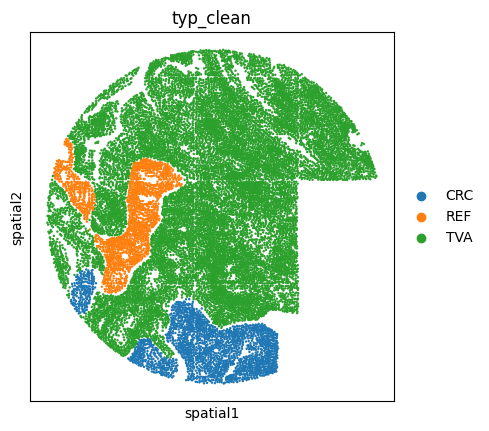

In [36]:
sc.pl.spatial(adata_sub[adata_sub.obs['sid'] == 231], color='typ_clean', spot_size=100)

/tmp/ipykernel_1705789/2136539241.py:1: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata_sub[adata_sub.obs['sid'] == 242], color='typ_clean', spot_size=100)
/data/a330d/miniforge3/envs/cellina-graph/lib/python3.10/site-packages/scanpy/plotting/_utils.py:465: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[f"{value_to_plot}_colors"] = colors_list


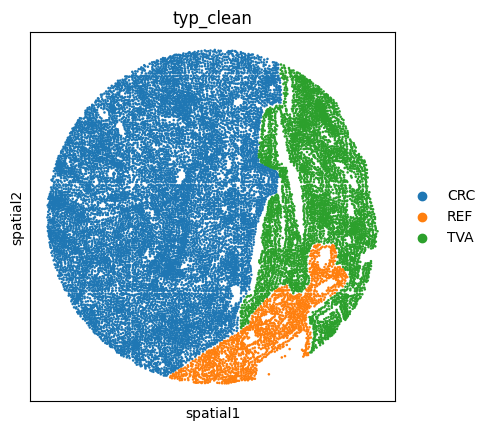

In [37]:
sc.pl.spatial(adata_sub[adata_sub.obs['sid'] == 242], color='typ_clean', spot_size=100)

In [41]:
adata_sub.uns = adata.uns

In [42]:
adata_sub.uns['default_params']['test_samples'] = False
adata_sub.uns['default_params']['n_holdout'] = 0
adata_sub.uns['default_params']['dataset_name'] = "crc_simvi"

In [43]:
adata_sub.uns['default_params']

{'K_NN': np.int64(50),
 'batch_key': 'sid',
 'celltype_key': 'coarse_type',
 'dataset_name': 'crc_simvi',
 'n_holdout': 0,
 'n_val_samples': np.False_,
 'niche_key': 'typ_clean',
 'sample_key': 'sid',
 'test_samples': False,
 'train_frac': np.float64(0.8)}

In [44]:
adata_sub.write_h5ad(f"{base_path}/processed/crc_simvi.h5ad")